In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 연관규칙 학습
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth

# 파이프라인
from sklearn.pipeline import Pipeline

# KDE를 그리기 위한 통계값을 구할 수 있는 함수
from scipy.stats import gaussian_kde

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 데이터 불러오기

In [2]:
train_df = pd.read_csv('data/titanic_train.csv')
test_df = pd.read_csv('data/titanic_test.csv')

print(train_df)
print('='*60)
print(test_df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

### 사망 생존 데이터 분석

In [3]:
# 도수 분포 확인
r1 = train_df['Survived'].value_counts()
r1.index = ['사망','생존']
r1

사망    549
생존    342
Name: count, dtype: int64

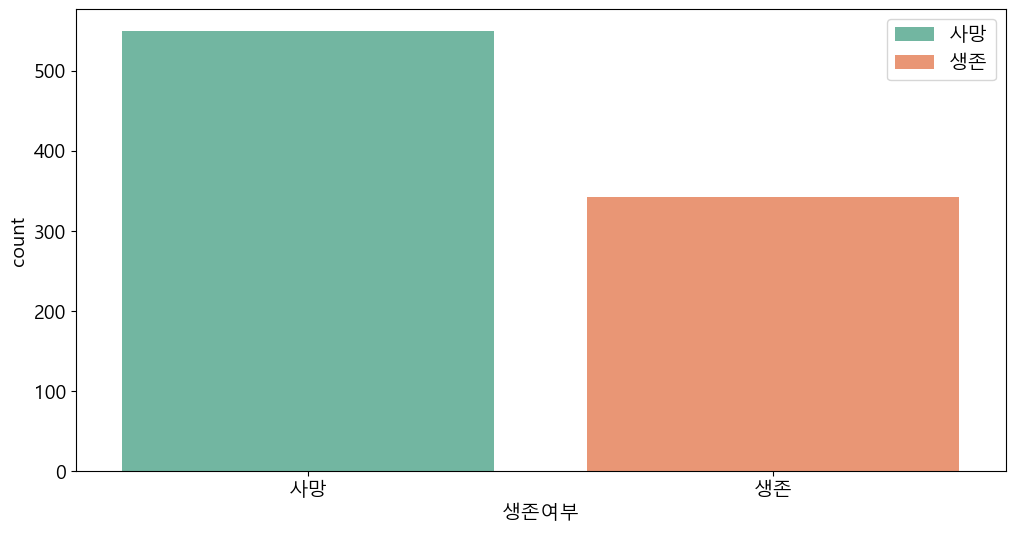

In [4]:
# 시각화
sns.countplot(data=train_df, x='Survived', palette='Set2', hue='Survived')
plt.xticks([0,1],['사망','생존'])
plt.legend(labels=['사망','생존'])
plt.xlabel('생존여부')
plt.show()

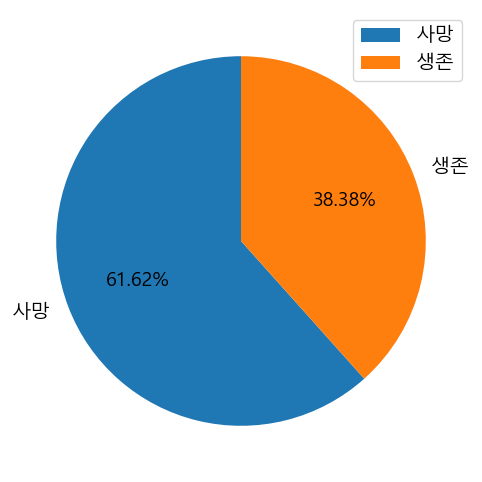

In [5]:
r1 = train_df['Survived'].value_counts()
r1.plot.pie(startangle=90, autopct='%.2f%%', labels=['사망','생존'])
plt.legend()
plt.show()

### PassengerId
- 승객번호
- 1부터 1씩 증가시킨 숫자를 부여한 것
- 제거 대상

### Pclass 
- 객실등급
- 1 = 1등석, 2 = 2등석, 3 = 3등석

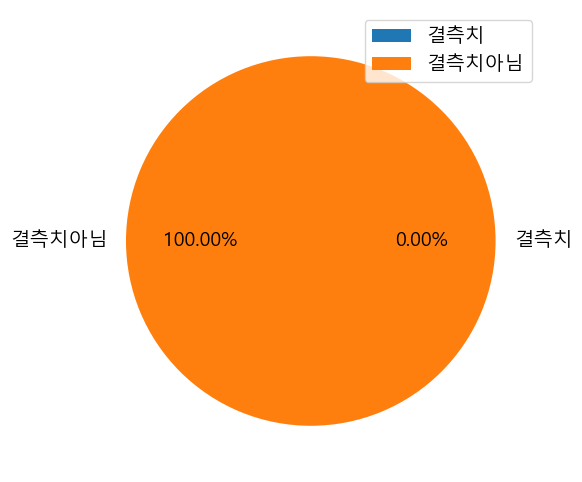

In [6]:
# 결측치를 확인한다
a1 = train_df['Pclass'].isna().sum()
a2 = train_df['Pclass'].notna().sum()

plt.pie([a1,a2], labels=['결측치', '결측치아님'], autopct='%.2f%%')
plt.legend()
plt.show()

In [7]:
# 도수 분포
r1 = train_df['Pclass'].value_counts()
r1.sort_index(inplace=True)
r1.index = ['1등석','2등석','3등석']
r1

1등석    216
2등석    184
3등석    491
Name: count, dtype: int64

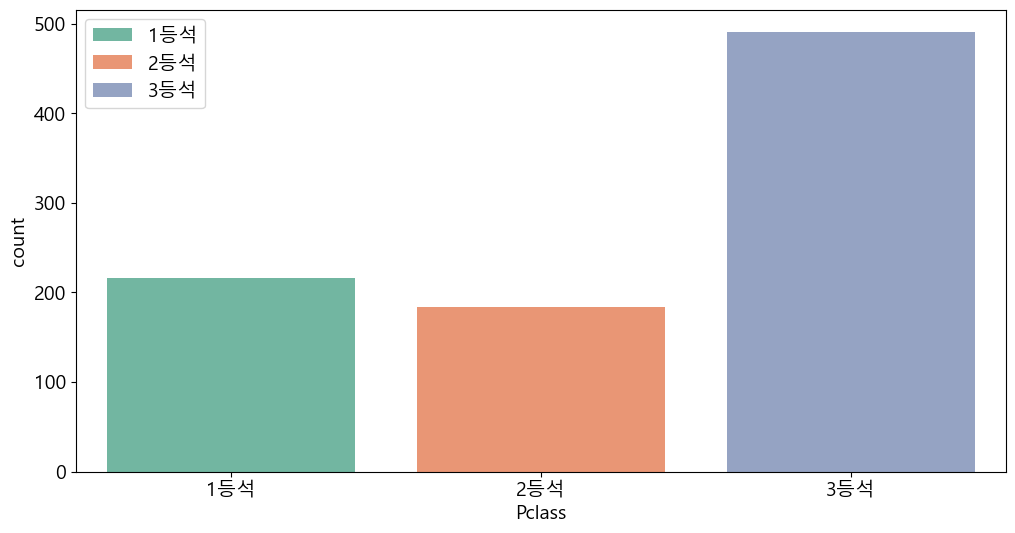

In [8]:
sns.countplot(data=train_df, x='Pclass', palette='Set2', hue='Pclass')
plt.xticks([0,1,2], ['1등석','2등석','3등석'])
plt.legend(labels=['1등석','2등석','3등석'])
plt.show()

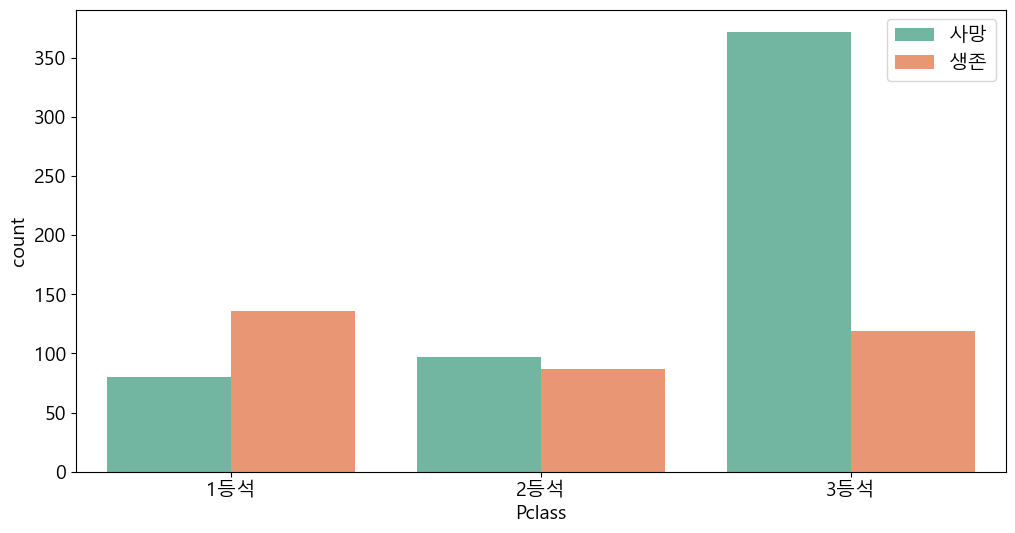

In [9]:
sns.countplot(data=train_df, x='Pclass', palette='Set2', hue='Survived')
plt.xticks([0,1,2], ['1등석','2등석','3등석'])
plt.legend(labels=['사망','생존'])
plt.show()

- 3등석의 승객이 월등히 많다
- 1등석은 생존비율이 높으며, 2등석은 사망 비율이 높지만 거의 차이가 없다. 3등석은 사망 비율이 매우 높다

# Name
- 승객이름

([<matplotlib.patches.Wedge at 0x284f1ee5ee0>,
 [Text(1.1, 0.0, '결측치'),
  Text(-1.0999999999999959, -9.616505800409723e-08, '결측치아님')],
 [Text(0.6, 0.0, '0.00%'),
  Text(-0.5999999999999978, -5.2453668002234845e-08, '100.00%')])

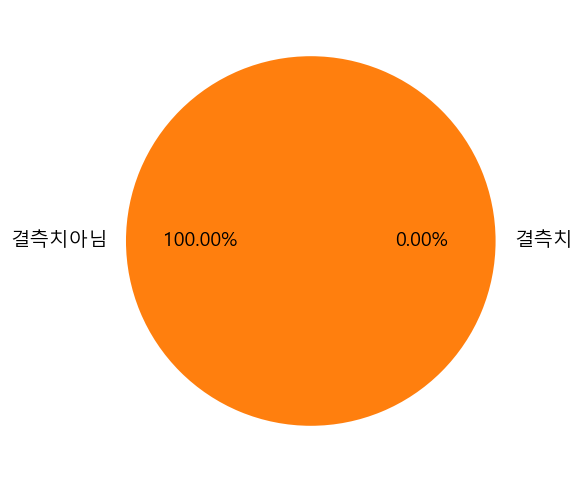

In [10]:
a1 = train_df['Name'].isna().sum()
a2 = train_df['Name'].notna().sum()

plt.pie([a1,a2], labels=['결측치','결측치아님'], autopct='%.2f%%')

In [11]:
train_df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [12]:
# 가운데 있는 Title(Mr. Mrs.등)을 추출하여 Title이라는 컬럼에 담아준다.
# 공백 + 알파벳 글자들 + 마침표(.) 의 패턴 부분을 찾는다.
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [13]:
# Title의 도수 분포를 확인한다
train_df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [14]:
# 비슷한 호칭끼리 묶기
# Mlle : 프랑스어로 마드무어젤, 결혼하지않은 미혼 여성을 뜻함(Miss로 변경)
# Mme : 프랑스어로 마담. 결혼한 기혼 여성을 뜻함 (Mrs 로 변경)
# Ms : 영어권 호칭, 혼인 여부와 상관없이 여성을 부를 때 사용한다. (Miss로 변경)
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms', 'Mme'],['Miss','Miss','Mrs'])
test_df['Title'] = test_df['Title'].replace(['Mlle', 'Ms', 'Mme'],['Miss','Miss','Mrs'])

In [15]:
train_df['Title'].value_counts()

Title
Mr          517
Miss        185
Mrs         126
Master       40
Dr            7
Rev           6
Major         2
Col           2
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [16]:
test_df['Title'].value_counts()

Title
Mr        240
Miss       79
Mrs        72
Master     21
Col         2
Rev         2
Dr          1
Dona        1
Name: count, dtype: int64

In [17]:
# Mr, Miss, Mrs, Master가 아니라면 Rare로 변경 (수가 적은걸 묶어버리자)
a1 = ['Mr', 'Miss', 'Mrs', 'Master']

idx1 = train_df.query('Title not in @a1').index
idx2 = test_df.query('Title not in @a1').index

train_df.loc[idx1, 'Title'] = 'Rare'
test_df.loc[idx2, 'Title'] = 'Rare'

In [18]:
train_df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [19]:
test_df['Title'].value_counts()

Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64

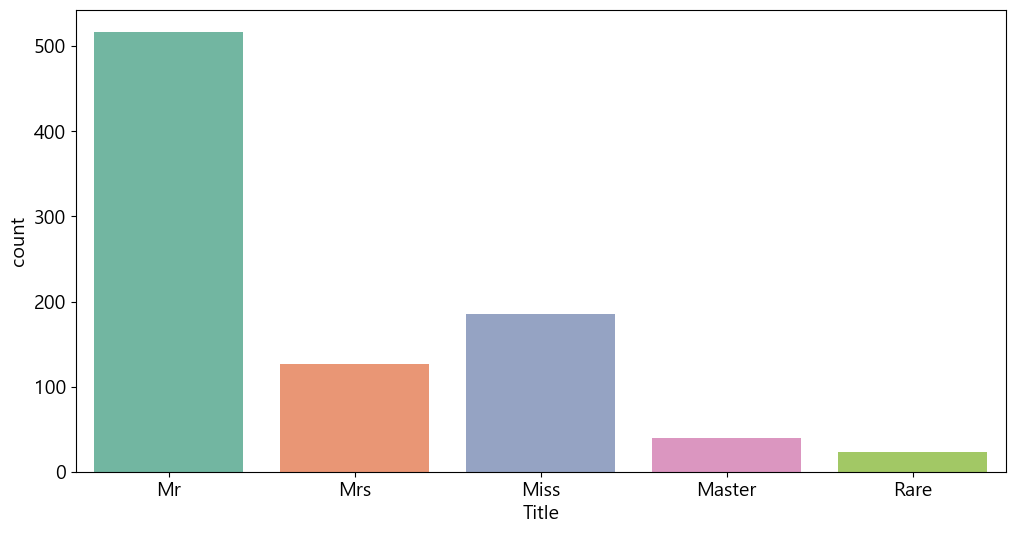

In [20]:
sns.countplot(data=train_df, x='Title', palette='Set2', hue='Title')
plt.show()

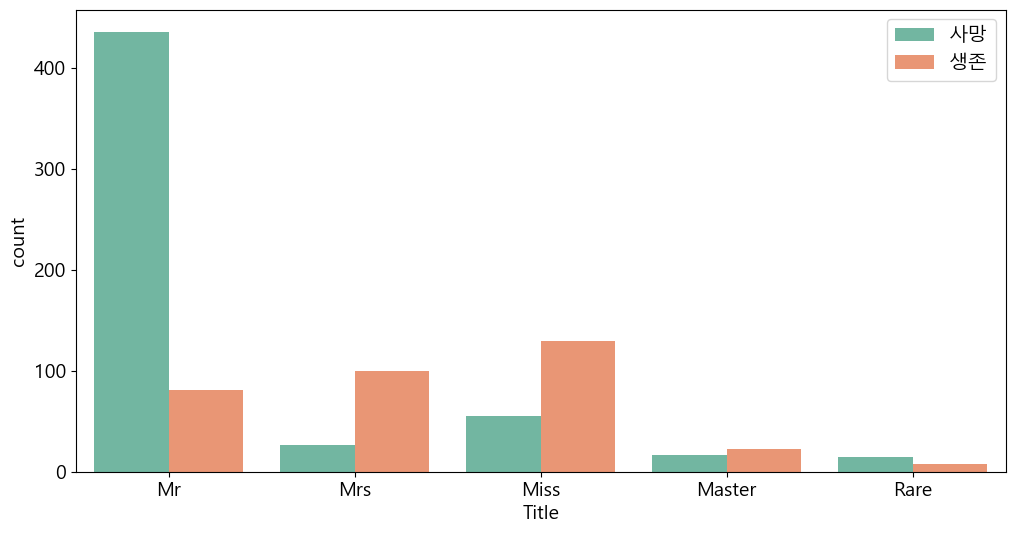

In [21]:
sns.countplot(data=train_df, x='Title', palette='Set2', hue='Survived')
plt.legend(labels=['사망','생존'])
plt.show()

- Mr는 사망비율이 높다
- Mrs, Miss 는 생존 비율이 높다
- 나머지는 비슷하다.

### Sex
- 성별
- male : 남성, female : 여성

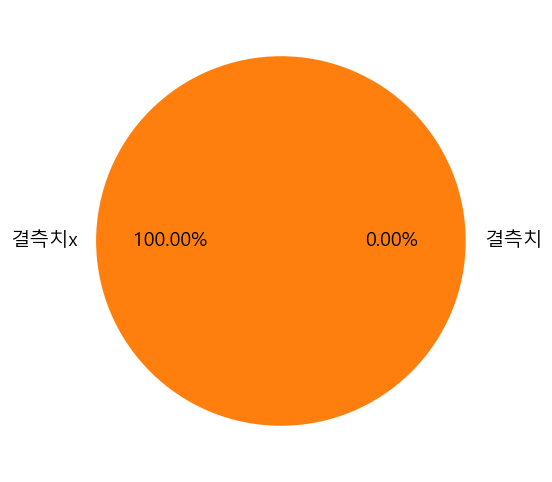

In [22]:
a1 = train_df['Sex'].isna().sum()
a2 = train_df['Sex'].notna().sum()

plt.pie([a1,a2], labels=['결측치','결측치x'], autopct='%.2f%%')
plt.show()

In [23]:
# 도수 분포 확인
train_df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

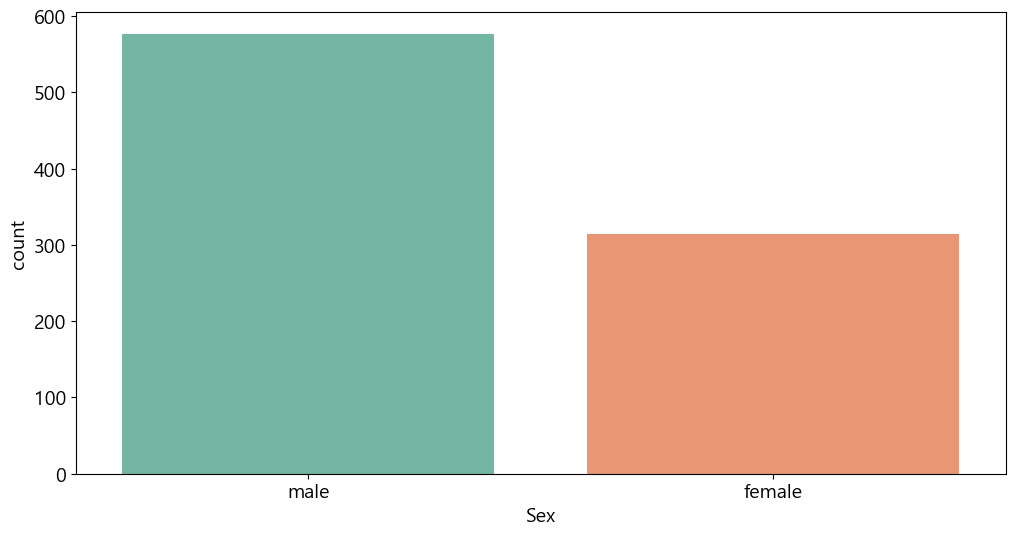

In [24]:
# 시각화
sns.countplot(data=train_df, x='Sex', palette='Set2', hue='Sex')
plt.show()

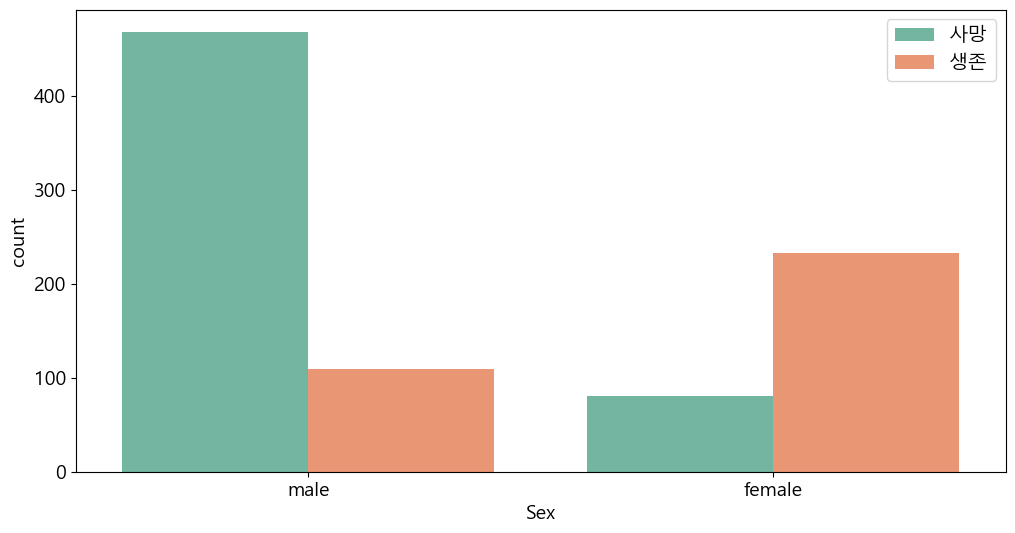

In [25]:
sns.countplot(data=train_df, x='Sex', palette='Set2', hue='Survived')
plt.legend(labels=['사망','생존'])
plt.show()

- 남성은 사망 비율이 높다.
- 여성은 생존 비율이 높다.

### Age
- 나이

([<matplotlib.patches.Wedge at 0x284f23f5e80>,
 [Text(0.8926463816554828, 0.6427926861106729, '결측치'),
  Text(-0.8926462488338809, -0.6427928705600285, '결측치아님')],
 [Text(0.48689802635753604, 0.3506141924240034, '19.87%'),
  Text(-0.4868979539093895, -0.3506142930327428, '80.13%')])

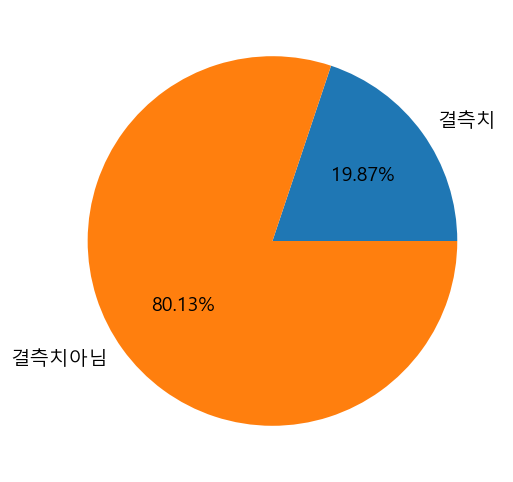

In [26]:
a1 = train_df['Age'].isna().sum()
a2 = train_df['Age'].notna().sum()

plt.pie([a1,a2], labels=['결측치','결측치아님'], autopct='%.2f%%')

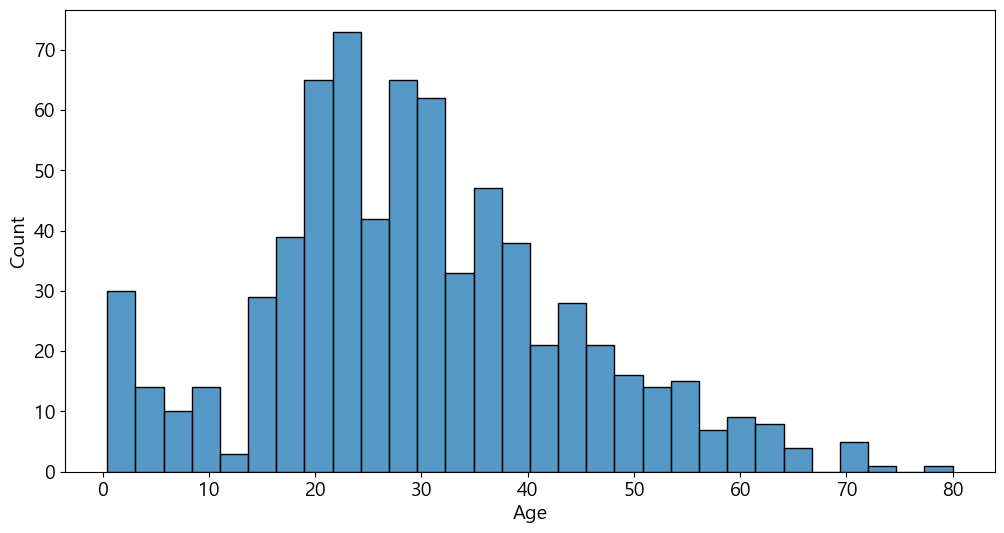

In [27]:
sns.histplot(data=train_df, x='Age', bins=30)
plt.show()

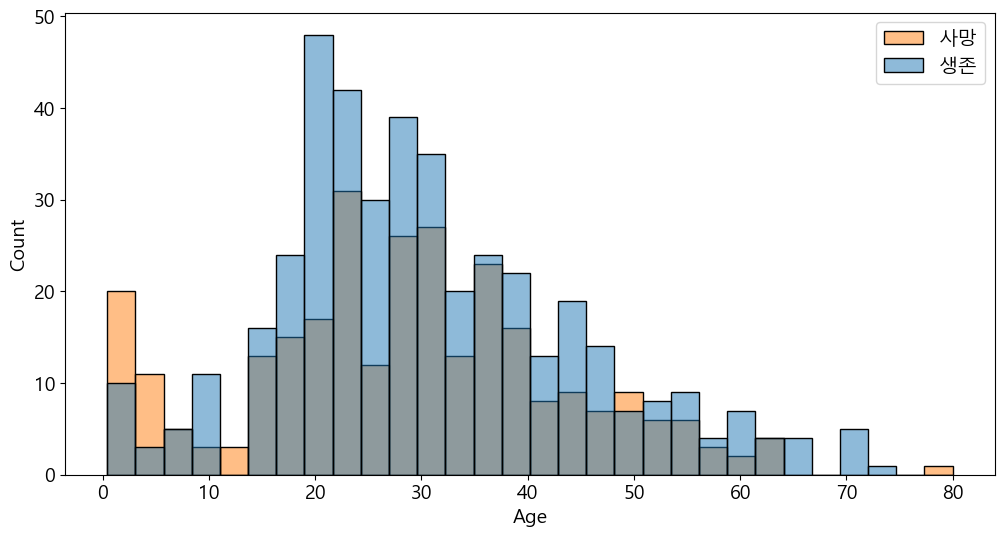

In [28]:
sns.histplot(data=train_df, x='Age', bins=30, hue='Survived')
plt.legend(labels=['사망','생존'])
plt.show()

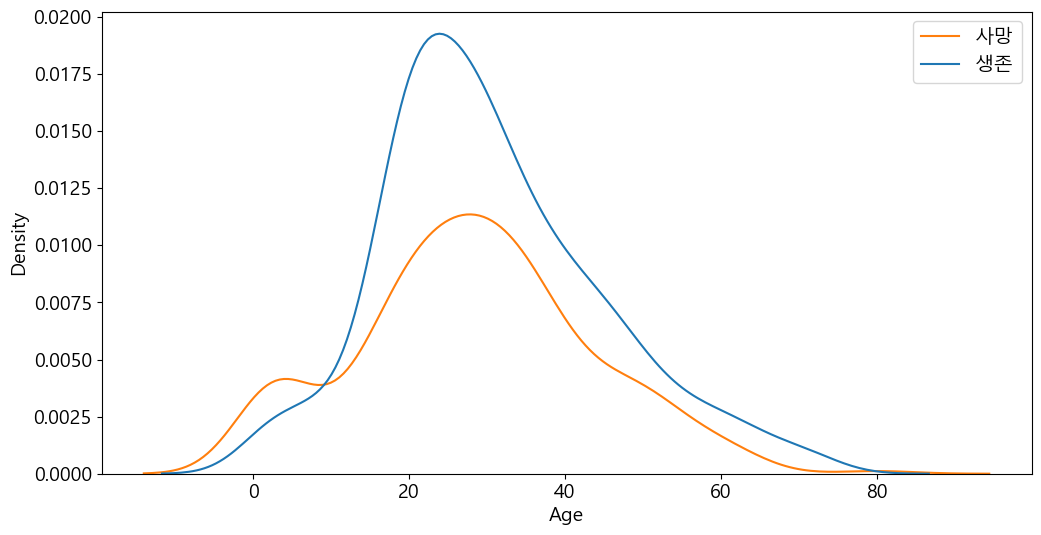

In [29]:
sns.kdeplot(data=train_df, x='Age', hue='Survived')
plt.legend(labels=['사망','생존'])
plt.show()

- 어릴 때는 생존비율이 높다
- 특정 나이 이후로는 사망 비율이 높다

### 어린이 여부 컬럼을 생성한다

In [30]:
# 결측치인 데이터는 제거한다.
notna_df = train_df.dropna(subset='Age')
notna_df['Age'].isna().sum()

np.int64(0)

In [31]:
# 사망과 생존으로 나눈다.
age_survived = notna_df.query('Survived == 1')['Age']
age_died = notna_df.query('Survived == 0')['Age']

In [32]:
# X 축 범위 설정
X_range = np.linspace(0, notna_df['Age'].max(), 1000)

In [33]:
# 각각의 KDE 곡선 계산
kde_survived = gaussian_kde(age_survived)(X_range)
kde_died = gaussian_kde(age_died)(X_range)

In [34]:
# 두 곡선이 만나는 지점을 찾는다(차이의 절대값이 최소가 되는 지점)
diff = kde_survived - kde_died
idx = np.where(np.diff(np.sign(diff)))[0]

In [35]:
# 결과를 가져온다.
intersection_ages = X_range[idx]
print(f'생존율이 연전되는 나이 지점들 : {intersection_ages}')

생존율이 연전되는 나이 지점들 : [13.61361361 30.67067067 40.28028028 49.00900901 57.17717718 78.7987988 ]


In [36]:
# isChild 컬럼을 추가
train_df['isChild'] = train_df['Age']
test_df['isChild'] = test_df['Age']

In [37]:
# 나이 기준값 보다 작은 행들의 인덱스
a1 = intersection_ages[0]
idx1 = train_df.query('Age < @a1').index
idx2 = test_df.query('Age < @a1').index

# 1로 채워준다.
train_df.loc[idx1, 'isChild'] = 1
test_df.loc[idx2, 'isChild'] = 1

In [38]:
# 나이 기준값 이상인 행들의 인덱스
a1 = intersection_ages[0]
idx1 = train_df.query('Age >= @a1').index
idx2 = test_df.query('Age >= @a1').index

# 1로 채워준다.
train_df.loc[idx1, 'isChild'] = 0
test_df.loc[idx2, 'isChild'] = 0

In [39]:
print(train_df['Age'].isna().sum())
print(train_df['isChild'].isna().sum())
print(test_df['Age'].isna().sum())
print(test_df['isChild'].isna().sum())

177
177
86
86


In [40]:
# 도수 분포
a1 = train_df['isChild'].value_counts()
a1.index = ['어린이아님', '어린이']
a1

어린이아님    643
어린이       71
Name: count, dtype: int64

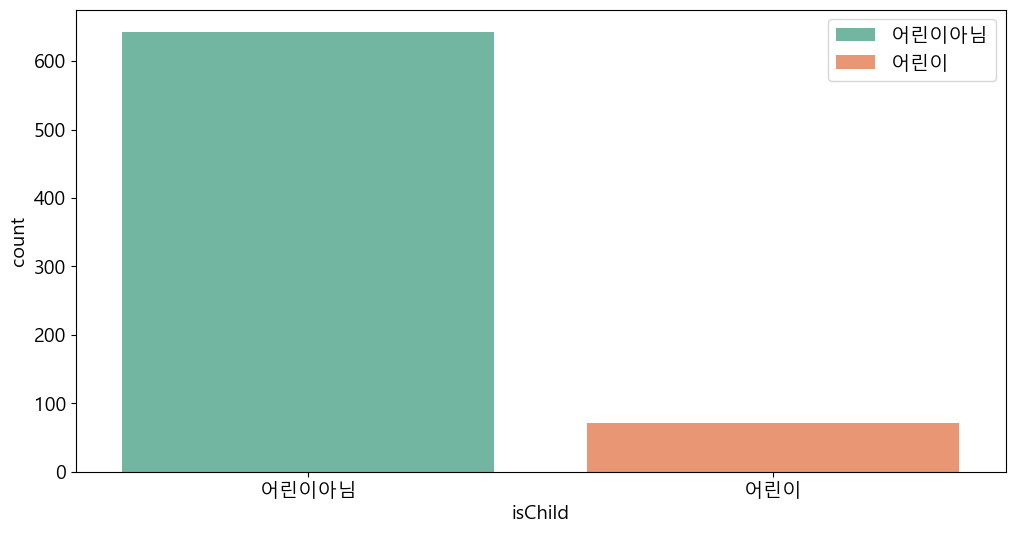

In [41]:
sns.countplot(data=train_df, x='isChild', palette='Set2', hue='isChild')
plt.xticks([0,1],['어린이아님','어린이'])
plt.legend(labels=['어린이아님','어린이'])
plt.show()

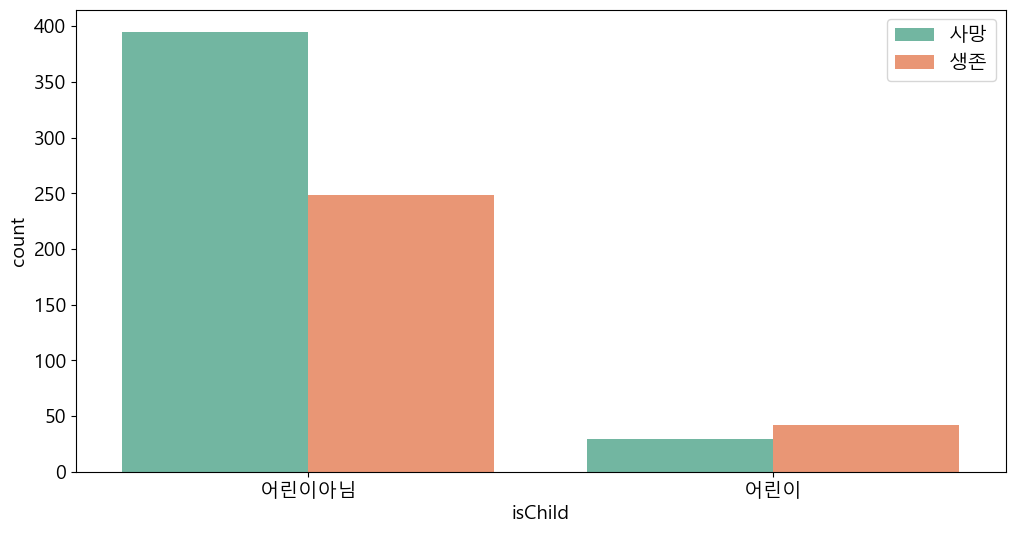

In [42]:
sns.countplot(data=train_df, x='isChild', palette='Set2', hue='Survived')
plt.xticks([0,1],['어린이아님','어린이'])
plt.legend(labels=['사망','생존'])
plt.show()

- 어린이가 아니면 사망 비율이 높다
- 어린이면 생존 비율이 높다

### Sibsp
- 함꼐 탑승한 형제, 자매, 배우자 수

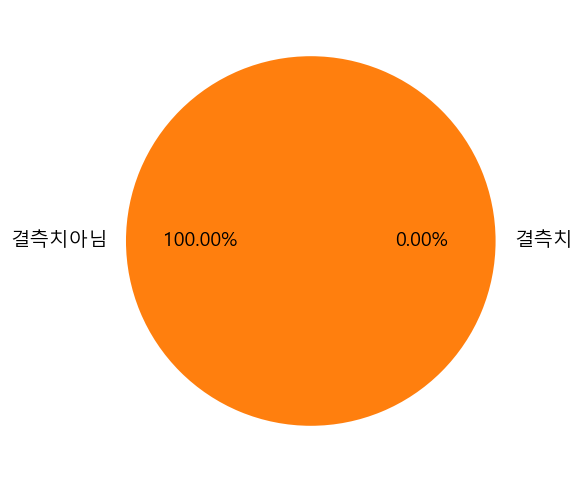

In [43]:
a1 = train_df['SibSp'].isna().sum()
a2 = train_df['SibSp'].notna().sum()

plt.pie([a1,a2], labels=['결측치','결측치아님'], autopct='%.2f%%')
plt.show()

In [44]:
train_df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

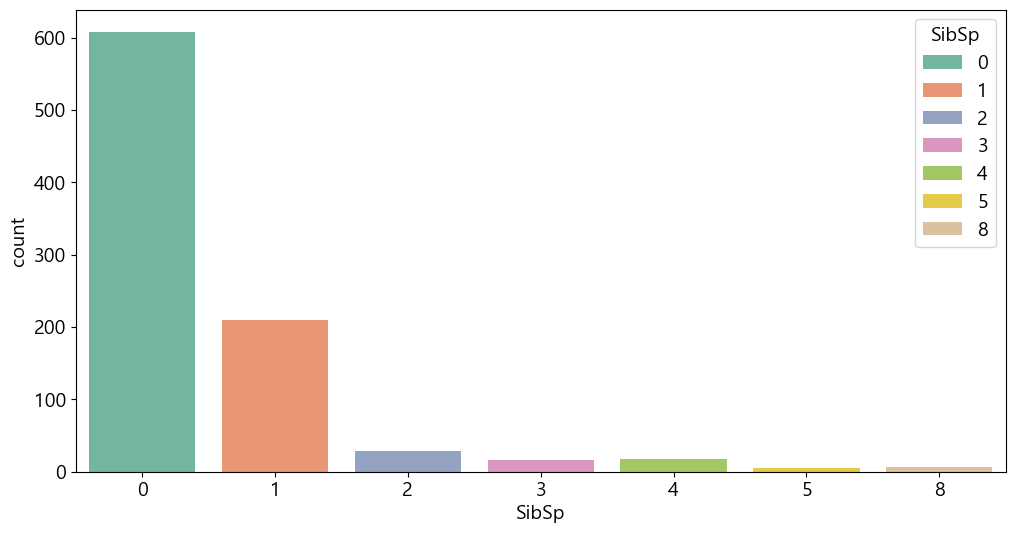

In [45]:
sns.countplot(data=train_df, x='SibSp', palette='Set2', hue='SibSp')
plt.show()

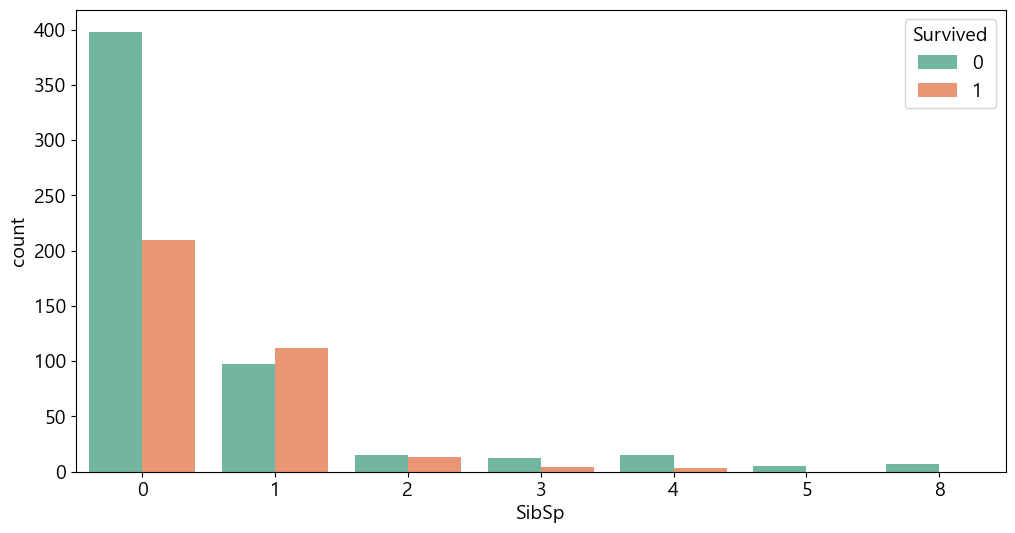

In [46]:
sns.countplot(data=train_df, x='SibSp', palette='Set2', hue='Survived')
plt.show()

- 동승한 형제, 자매, 배우자의 수가 0인 사람들은 사망 비율이 높다
- 1명인 사람은 생존비율이 높다
- 2명인 사람은 비슷하다
- 그 외는 사망 비율이 높다

### Parch
- 함께 탑승한 부모, 자녀의 수

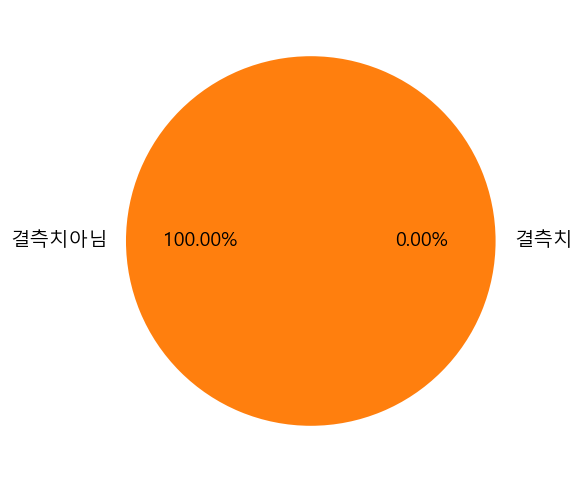

In [47]:
a1 = train_df['Parch'].isna().sum()
a2 = train_df['Parch'].notna().sum()

plt.pie([a1,a2], labels=['결측치','결측치아님'],autopct='%.2f%%')
plt.show()

In [48]:
train_df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

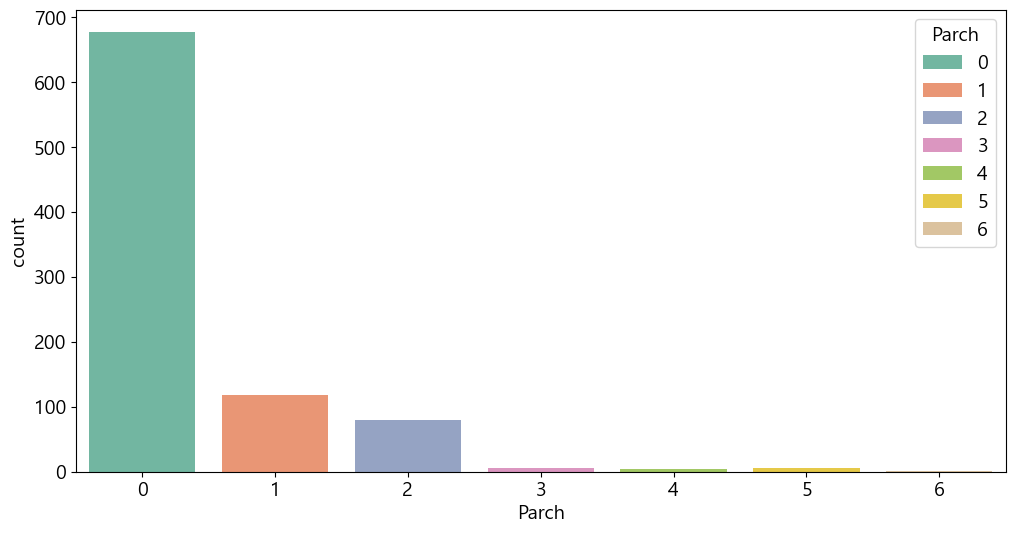

In [49]:
sns.countplot(data=train_df, x='Parch', palette='Set2', hue='Parch')
plt.show()

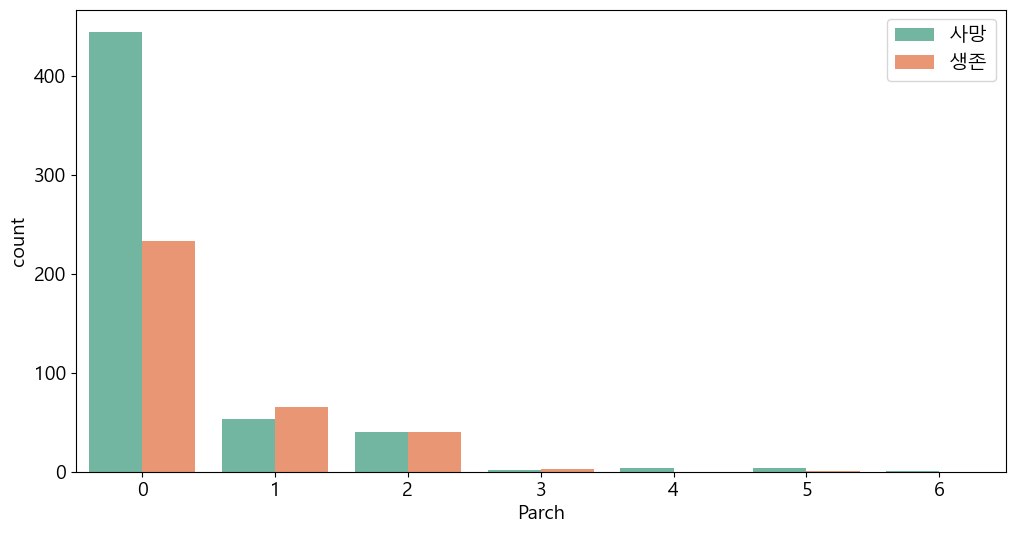

In [50]:
sns.countplot(data=train_df, x='Parch', palette='Set2', hue='Survived')
plt.legend(labels=['사망','생존'])
plt.show()

- 0명인 사람들은 사망 비율이 높다
- 1,2,3명인 사람들은 생존 비율이 높거나 비슷하다
- 나머지는 무시해도 될 정도로 표본 수가 매우 적다

### 가족 수
- SibSp 와 Parch를 합한 가족 수 컬럼을 발생한다.

In [51]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch']
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch']

In [52]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,isChild,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,0.0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,0.0,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0.0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,0.0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rare,0.0,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,0.0,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss,NaN,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,0.0,0


In [53]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,isChild,FamilySize
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,0.0,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,0.0,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,0.0,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,0.0,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Mr,NaN,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Rare,0.0,0
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr,0.0,0
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Mr,NaN,0


In [54]:
train_df['FamilySize'].value_counts()

FamilySize
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64

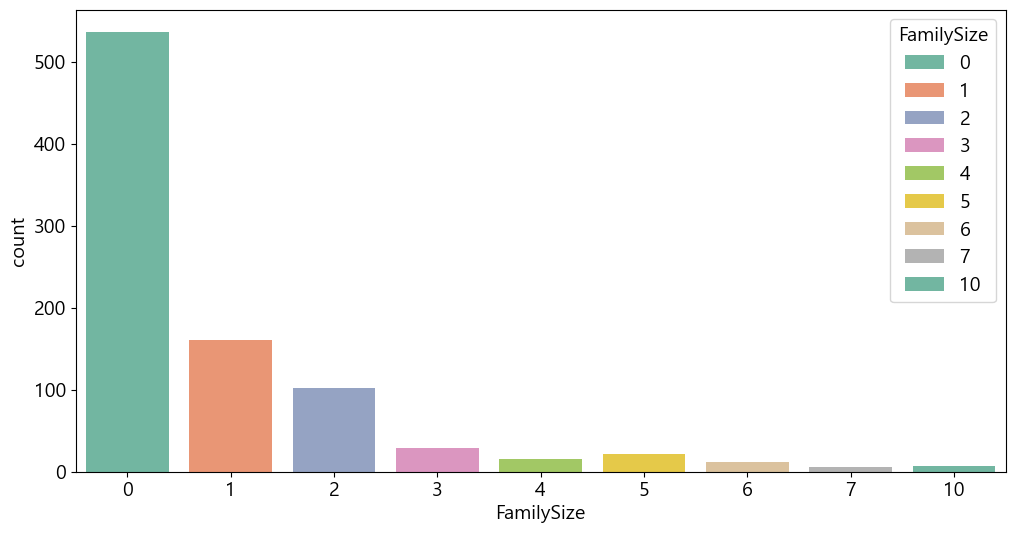

In [55]:
sns.countplot(data=train_df, x='FamilySize', palette='Set2', hue='FamilySize')
plt.show()

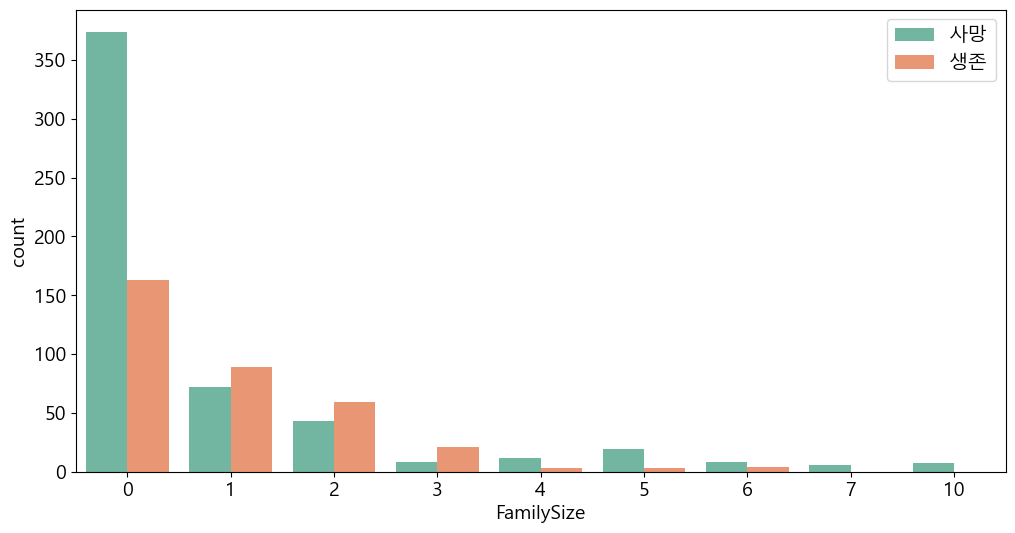

In [56]:
sns.countplot(data=train_df, x='FamilySize', palette='Set2', hue='Survived')
plt.legend(labels=['사망','생존'])
plt.show()

- 가족 수가 0명인 사람들은 사망 비율이 높다
- 가족 수가 1,2,3명인 사람들은 생존 비율이 높다
- 그 외는 사망 비율이 높다

### 가족 수 그룹 데이터 생성
- 위에서 분석한 내용을 토대로 가족수가 0명인 사람, 가족수가 1~3명인 사람 그 외의 사람으로 분류한 데이터를 발생 시킨다.

In [57]:
# 기본을 0으로 하여 컬럼을 추가한다.
train_df['FamilySizeGroup'] = 0
test_df['FamilySizeGroup'] = 0

In [58]:
# 가족 수가 1~3명인 사람들은 1로 셋팅된다.
idx1 = train_df.query('FamilySize >= 1 and FamilySize <= 3').index
idx2 = test_df.query('FamilySize >= 1 and FamilySize <= 3').index

train_df.loc[idx1, 'FamilySizeGroup'] = 1
test_df.loc[idx2, 'FamilySizeGroup'] = 1

In [59]:
# 그 외의 사람들은 2로 셋팅한다.
idx1 = train_df.query('FamilySize > 3').index
idx2 = test_df.query('FamilySize > 3').index

train_df.loc[idx1, 'FamilySizeGroup'] = 2
test_df.loc[idx2, 'FamilySizeGroup'] = 2

In [60]:
train_df['FamilySizeGroup'].value_counts()

FamilySizeGroup
0    537
1    292
2     62
Name: count, dtype: int64

In [61]:
test_df['FamilySizeGroup'].value_counts()

FamilySizeGroup
0    253
1    145
2     20
Name: count, dtype: int64

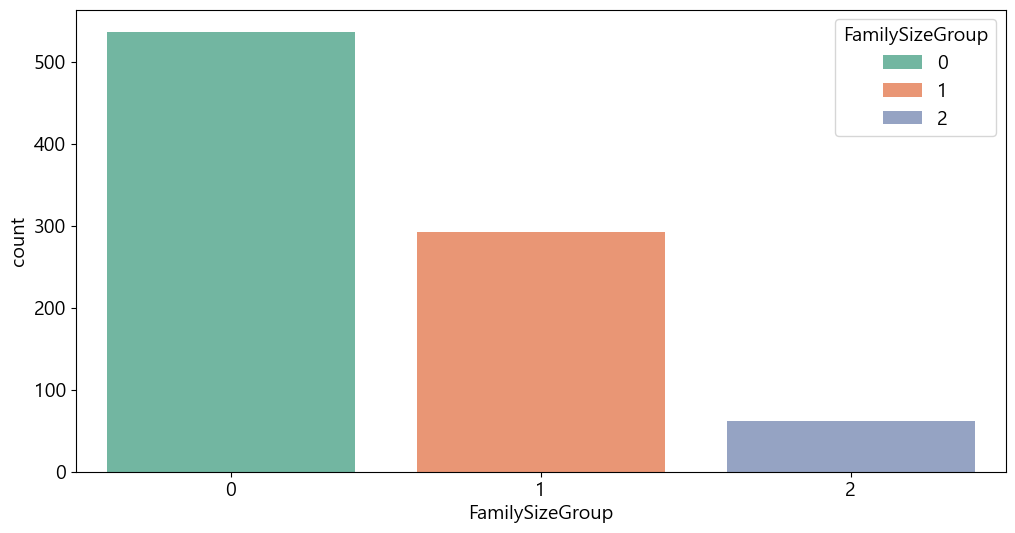

In [62]:
sns.countplot(data=train_df, x='FamilySizeGroup', palette='Set2', hue='FamilySizeGroup')
plt.show()

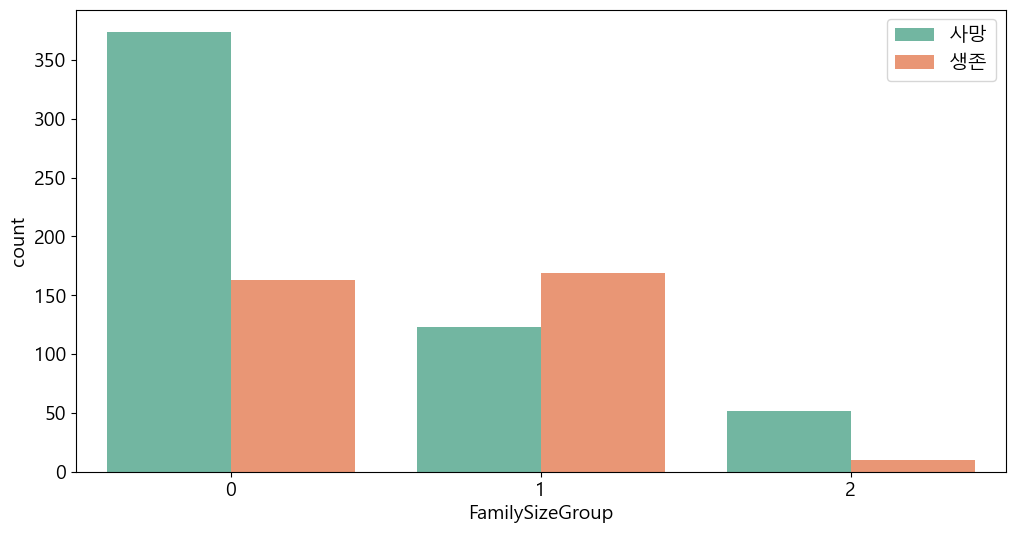

In [63]:
sns.countplot(data=train_df, x='FamilySizeGroup', palette='Set2', hue='Survived')
plt.legend(labels=['사망','생존'])
plt.show()

### Ticket
- 티켓번호

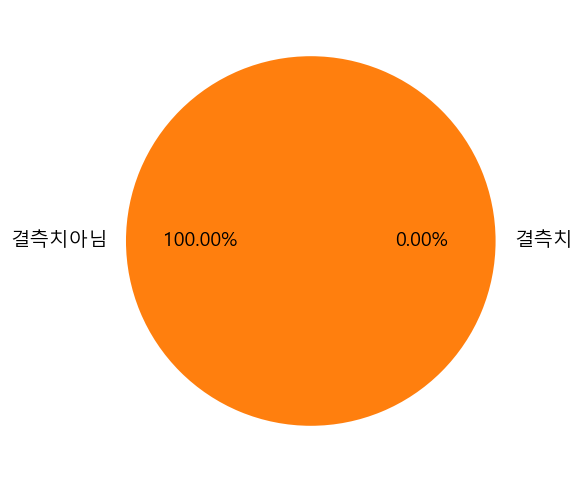

In [64]:
a1 = train_df['Ticket'].isna().sum()
a2 = train_df['Ticket'].notna().sum()

plt.pie([a1,a2], labels=['결측치','결측치아님'],autopct='%.2f%%')
plt.show()

In [65]:
train_df['Ticket'].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

- Ticket 번호는 분석이 불가능한 데이터로 제거한다.

### Fare
- 요금

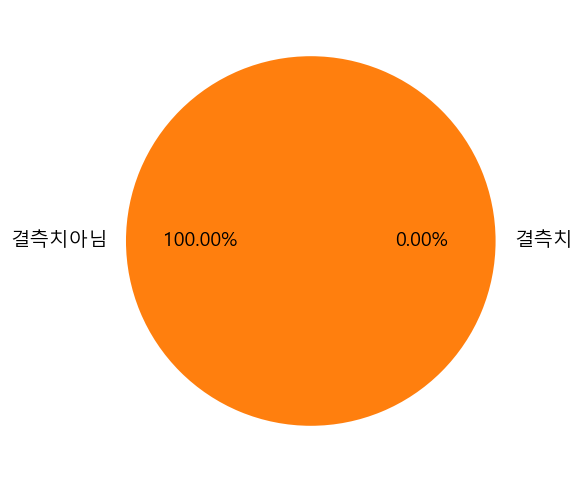

In [66]:
a1 = train_df['Fare'].isna().sum()
a2 = train_df['Fare'].notna().sum()

plt.pie([a1,a2], labels=['결측치','결측치아님'], autopct='%.2f%%')
plt.show()

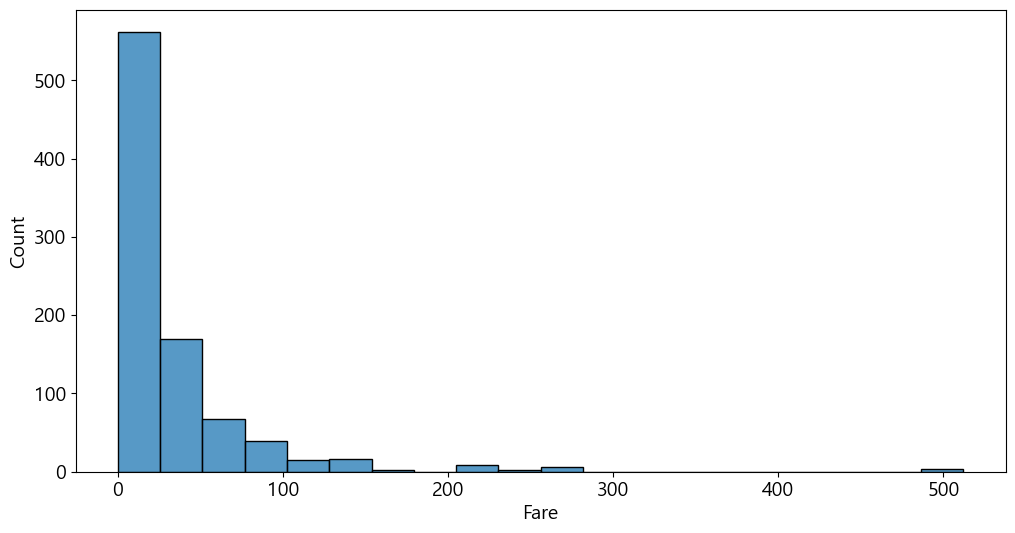

In [67]:
sns.histplot(data=train_df, x='Fare', bins=20)
plt.show()

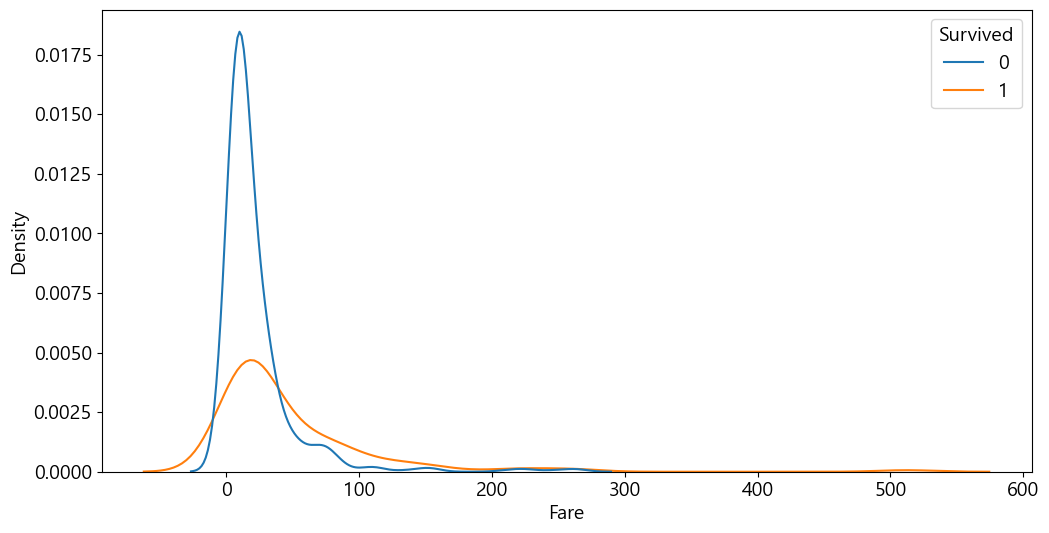

In [68]:
sns.kdeplot(data=train_df, x='Fare', hue='Survived')
plt.show()

In [69]:
# 데이터가 매우 불균형을 보이고 있고 이상치가 너무나 크기 때문에 로그값을 취해서 사용한다.
train_df['Fare'] = np.log1p(train_df['Fare'])
test_df['Fare'] = np.log1p(test_df['Fare'])

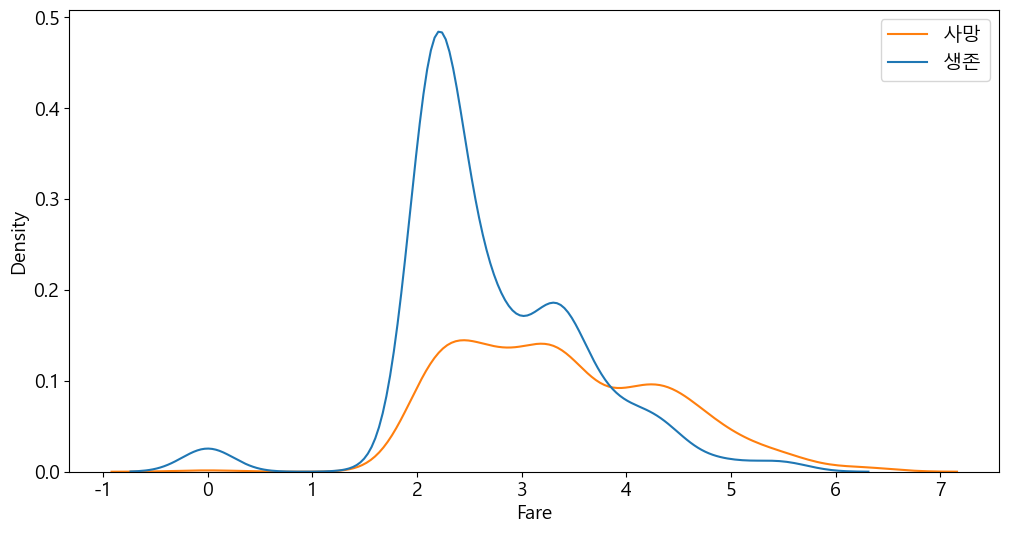

In [70]:
sns.kdeplot(data=train_df, x='Fare', hue='Survived')
plt.legend(labels=['사망','생존'])
plt.show()

- 요금 구간이 낮을수록 사망 비율이 높다

### Cabin
- 객실번호

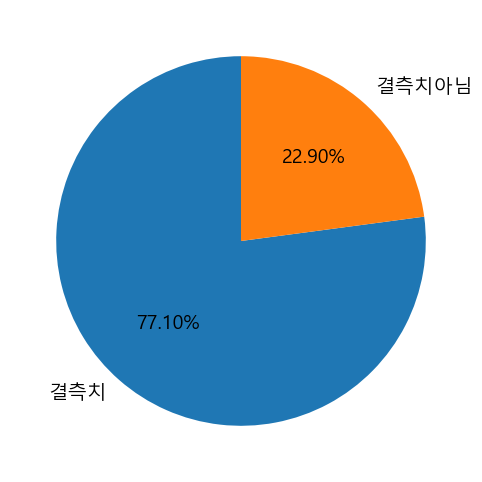

In [71]:
a1 = train_df['Cabin'].isna().sum()
a2 = train_df['Cabin'].notna().sum()

plt.pie([a1,a2], labels=['결측치','결측치아님'],autopct='%.2f%%', startangle=90)
plt.show()

- 결측치 비율이 70%가 넘으므로 제거한다.

### Embarked
- 탑승할 때 이용한 선착장 이름
- C = Cherbourg, Q = Queenstown, S = Southampton

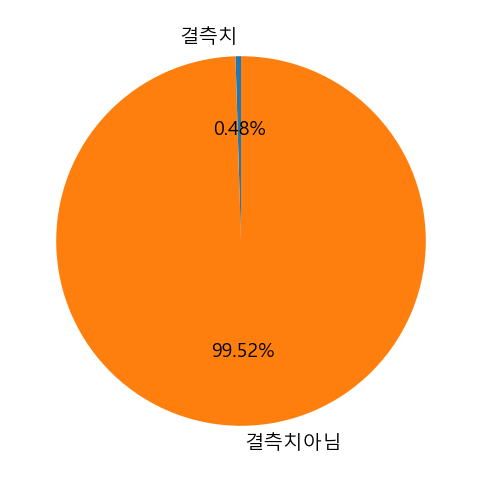

In [72]:
a1 = train_df['Embarked'].isna().sum()
a2 = test_df['Embarked'].notna().sum()
plt.pie([a1,a2], labels=['결측치','결측치아님'], autopct='%.2f%%', startangle=90)
plt.show()

In [73]:
train_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

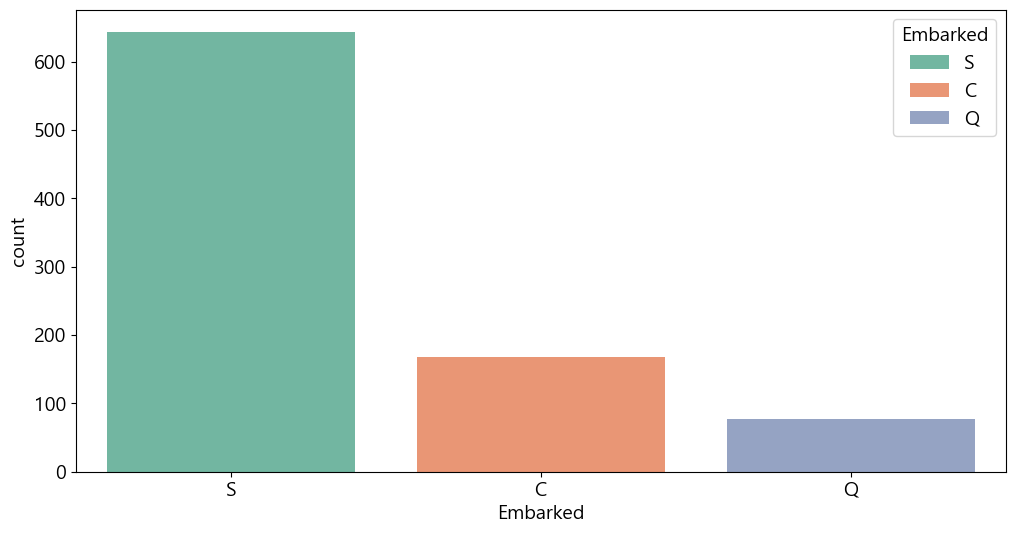

In [74]:
sns.countplot(data=train_df, x='Embarked', palette='Set2', hue='Embarked')
plt.show()

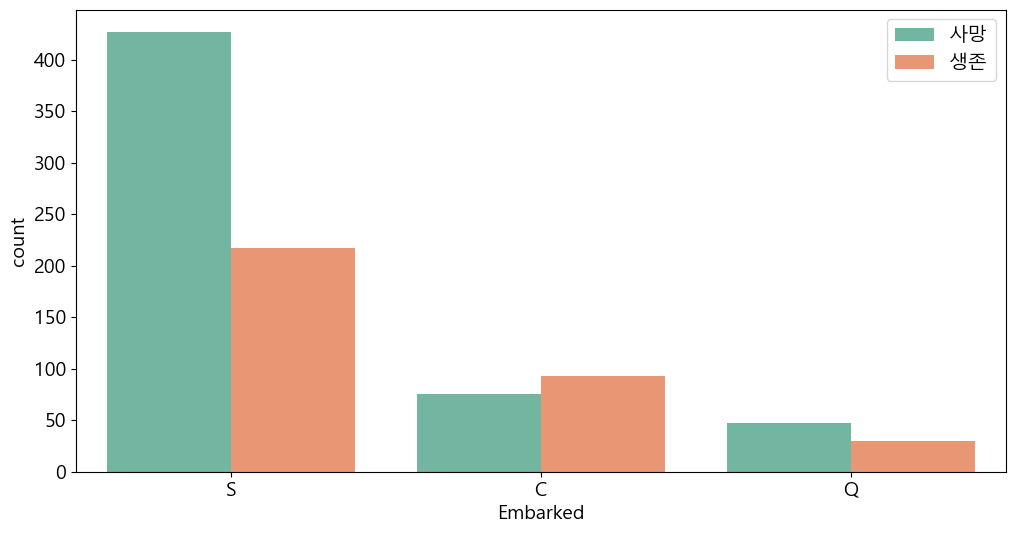

In [75]:
sns.countplot(data=train_df, x='Embarked', palette='Set2', hue='Survived')
plt.legend(labels=['사망','생존'])
plt.show()

- S 에서 탑승한 승객은 사망 비율이 높다
- C 에서 탑승한 승객은 생존 비율이 약간 높다
- Q 에서 탑승한 승객은 사망 비율이 약간 높다

### 불필요한 컬럼 제거

In [76]:
a1 = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train_df.drop(a1, axis=1, inplace=True)
train_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,isChild,FamilySize,FamilySizeGroup
0,0,3,male,22.0,1,0,2.110213,S,Mr,0.0,1,1
1,1,1,female,38.0,1,0,4.280593,C,Mrs,0.0,1,1
2,1,3,female,26.0,0,0,2.188856,S,Miss,0.0,0,0
3,1,1,female,35.0,1,0,3.990834,S,Mrs,0.0,1,1
4,0,3,male,35.0,0,0,2.202765,S,Mr,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,2.639057,S,Rare,0.0,0,0
887,1,1,female,19.0,0,0,3.433987,S,Miss,0.0,0,0
888,0,3,female,NaN,1,2,3.196630,S,Miss,NaN,3,1
889,1,1,male,26.0,0,0,3.433987,C,Mr,0.0,0,0


In [77]:
test_df.drop(a1, axis=1, inplace=True)
test_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,isChild,FamilySize,FamilySizeGroup
0,3,male,34.5,0,0,2.178064,Q,Mr,0.0,0,0
1,3,female,47.0,1,0,2.079442,S,Mrs,0.0,1,1
2,2,male,62.0,0,0,2.369075,Q,Mr,0.0,0,0
3,3,male,27.0,0,0,2.268252,S,Mr,0.0,0,0
4,3,female,22.0,1,1,2.586824,S,Mrs,0.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,2.202765,S,Mr,NaN,0,0
414,1,female,39.0,0,0,4.699571,C,Rare,0.0,0,0
415,3,male,38.5,0,0,2.110213,S,Mr,0.0,0,0
416,3,male,NaN,0,0,2.202765,S,Mr,NaN,0,0


In [78]:
train_df.to_csv('data/titanic_train2.csv', index=False)
test_df.to_csv('data/titanic_test2.csv', index=False)